In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
aws_land_raw = pd.read_csv("validation_sheet_Land.csv")
aws_ice_raw = pd.read_csv("validation_sheet_ice.csv")

In [ ]:
station_ice = "KPC_U"
station_land = "Zackenberg_M3"
period_start = "2022-07-01"
period_end = "2022-12-31"

In [ ]:
print(aws_ice_raw["aws"].value_counts())
print(aws_land_raw["aws"].value_counts())

In [ ]:
aws_ice_raw["date"] = pd.to_datetime(aws_ice_raw["date"])

aws_ice = aws_ice_raw[
    (aws_ice_raw["aws"] == station_ice) &
    (aws_ice_raw["date"] >= period_start) &
    (aws_ice_raw["date"] <= period_end)
].copy()

aws_land_raw["date"] = pd.to_datetime(aws_land_raw["Date"])
aws_land = aws_land_raw[
    (aws_land_raw["aws"] == station_land) &
    (aws_land_raw["date"] >= period_start) &
    (aws_land_raw["date"] <= period_end)
].copy()

print(len(aws_ice))
print(len(aws_land))

In [31]:
# ERA5
era5_land_raw = pd.read_csv("/home/sirsimsius/Dokumente/Arbeit/KU/GEMLST/GEMLST_MODIS/Data/ERA5/t2m_at_GEM_full.csv")
era5_ice_raw = pd.read_csv("/home/sirsimsius/Dokumente/Arbeit/KU/GEMLST/GEMLST_MODIS/Data/ERA5/t2m_at_PROMICE_full.csv")

def filter_era5_data(era5_raw, period_start, period_end):
    era5_raw["date"] = pd.to_datetime(era5_raw["id"])
    era5_filtered = era5_raw[
        (era5_raw["date"] >= period_start) &
        (era5_raw["date"] <= period_end)
    ].copy()
    return era5_filtered

def filter_era5_ice(era5_raw, period_start, period_end):
    era5_raw["date"] = pd.to_datetime(era5_raw["Unnamed: 0"])
    era5_filtered = era5_raw[
        (era5_raw["date"] >= period_start) &
        (era5_raw["date"] <= period_end)
    ].copy()
    return era5_filtered

era5_land = filter_era5_data(era5_land_raw, period_start, period_end)
era5_ice = filter_era5_ice(era5_ice_raw, period_start, period_end)

# era5_land.head()
# print(era5_ice_raw.columns)

Index(['Unnamed: 0', 'CEN', 'CP1', 'DY2', 'EGP', 'HUM', 'JAR', 'KAN_L',
       'KAN_M', 'KAN_T', 'KAN_U', 'KPC_L', 'KPC_U', 'NAE', 'NAU', 'NEM', 'NSE',
       'NUK_L', 'NUK_N', 'NUK_U', 'QAS_A', 'QAS_L', 'QAS_M', 'QAS_U', 'RED_L',
       'SCO_L', 'SCO_U', 'SDL', 'SDM', 'SWC', 'TAS_A', 'TAS_L', 'TAS_U',
       'THU_L', 'THU_L2', 'THU_U', 'TUN', 'UPE_L', 'UPE_U', 'WEG_L', 'date'],
      dtype='object')


In [ ]:
# JAXA G-COM 
sgli_land_a_raw = pd.read_csv("/home/sirsimsius/Dokumente/Arbeit/KU/GEMLST/GEMLST_MODIS/Data/LST_Extractions/JAXA/GEM_2024_AWS_JAXA_A_LST.csv")
sgli_land_d_raw = pd.read_csv("/home/sirsimsius/Dokumente/Arbeit/KU/GEMLST/GEMLST_MODIS/Data/LST_Extractions/JAXA/GEM_2024_AWS_JAXA_D_LST.csv")
sgli_ice_a_raw = pd.read_csv("/home/sirsimsius/Dokumente/Arbeit/KU/GEMLST/GEMLST_MODIS/Data/LST_Extractions/JAXA/JAXA_A_LST_PROMICE.csv")
sgli_ice_d_raw = pd.read_csv("/home/sirsimsius/Dokumente/Arbeit/KU/GEMLST/GEMLST_MODIS/Data/LST_Extractions/JAXA/JAXA_D_LST_PROMICE.csv")

def filter_sgli_data(df, station, period_start, period_end):
    df["date"] = pd.to_datetime(df["date"])
    filtered_df = df[
        (df["id"] == station) &
        (df["date"] >= period_start) &
        (df["date"] <= period_end)
    ].copy()
    return filtered_df

sgli_land_a = filter_sgli_data(sgli_land_a_raw, station_land, period_start, period_end)
sgli_land_d = filter_sgli_data(sgli_land_d_raw, station_land, period_start, period_end)
sgli_ice_a = filter_sgli_data(sgli_ice_a_raw, station_ice, period_start, period_end)
sgli_ice_d = filter_sgli_data(sgli_ice_d_raw, station_ice, period_start, period_end)

print(len(sgli_land_a))
print(len(sgli_land_d))
print(len(sgli_ice_a))
print(len(sgli_ice_d))


In [ ]:
mod_day_land_raw = pd.read_csv("/home/sirsimsius/Dokumente/Arbeit/KU/GEMLST/GEMLST_MODIS/Data/LST_Extractions/MODIS/GEM_2022_AWS_MOD_DAY_LST_bit6lte1.csv")
mod_night_land_raw = pd.read_csv("/home/sirsimsius/Dokumente/Arbeit/KU/GEMLST/GEMLST_MODIS/Data/LST_Extractions/MODIS/GEM_2022_AWS_MOD_NIGHT_LST_bit6lte1.csv")
mod_day_ice_raw = pd.read_csv("/home/sirsimsius/Dokumente/Arbeit/KU/GEMLST/GEMLST_MODIS/Data/LST_Extractions/MODIS/MOD_DAY_LST_PROMICE_after2022.csv")
mod_night_ice_raw = pd.read_csv("/home/sirsimsius/Dokumente/Arbeit/KU/GEMLST/GEMLST_MODIS/Data/LST_Extractions/MODIS/MOD_NIGHT_LST_PROMICE_after2022.csv")

myd_day_land_raw = pd.read_csv("/home/sirsimsius/Dokumente/Arbeit/KU/GEMLST/GEMLST_MODIS/Data/LST_Extractions/MODIS/GEM_2022_AWS_MYD_DAY_LST_bit6lte1.csv")
myd_night_land_raw = pd.read_csv("/home/sirsimsius/Dokumente/Arbeit/KU/GEMLST/GEMLST_MODIS/Data/LST_Extractions/MODIS/GEM_2022_AWS_MYD_NIGHT_LST_bit6lte1.csv")
myd_day_ice_raw = pd.read_csv("/home/sirsimsius/Dokumente/Arbeit/KU/GEMLST/GEMLST_MODIS/Data/LST_Extractions/MODIS/MYD_DAY_LST_PROMICE_after2022.csv")
myd_night_ice_raw = pd.read_csv("/home/sirsimsius/Dokumente/Arbeit/KU/GEMLST/GEMLST_MODIS/Data/LST_Extractions/MODIS/MYD_NIGHT_LST_PROMICE_after2022.csv")

def filter_modis_data(df, station, period_start, period_end):
    df["date"] = pd.to_datetime(df["date"])
    filtered_df = df[
        (df["id"] == station) &
        (df["date"] >= period_start) &
        (df["date"] <= period_end)
    ].copy()
    return filtered_df

mod_day_land = filter_modis_data(mod_day_land_raw, station_land, period_start, period_end)
mod_night_land = filter_modis_data(mod_night_land_raw, station_land, period_start, period_end)
mod_day_ice = filter_modis_data(mod_day_ice_raw, station_ice, period_start, period_end)
mod_night_ice = filter_modis_data(mod_night_ice_raw, station_ice, period_start, period_end)

myd_day_land = filter_modis_data(myd_day_land_raw, station_land, period_start, period_end)
myd_night_land = filter_modis_data(myd_night_land_raw, station_land, period_start, period_end)
myd_day_ice = filter_modis_data(myd_day_ice_raw, station_ice, period_start, period_end)
myd_night_ice = filter_modis_data(myd_night_ice_raw, station_ice, period_start, period_end)

print(len(mod_day_land))
print(len(mod_night_land))
print(len(mod_day_ice))
print(len(mod_night_ice))
print(len(myd_day_land))
print(len(myd_night_land))
print(len(myd_day_ice))
print(len(myd_night_ice))

In [ ]:
viirs_day_land_raw = pd.read_csv("/home/sirsimsius/Dokumente/Arbeit/KU/GEMLST/GEMLST_MODIS/Data/LST_Extractions/VIIRS/GEM_AWS_VIIRS_DAY_LST.csv")
viirs_night_land_raw = pd.read_csv("/home/sirsimsius/Dokumente/Arbeit/KU/GEMLST/GEMLST_MODIS/Data/LST_Extractions/VIIRS/GEM_AWS_VIIRS_NIGHT_LST.csv")
viirs_day_ice_raw = pd.read_csv("/home/sirsimsius/Dokumente/Arbeit/KU/GEMLST/GEMLST_MODIS/Data/LST_Extractions/VIIRS/VIIRS_DAY_LST_PROMICE.csv")
viirs_night_ice_raw = pd.read_csv("/home/sirsimsius/Dokumente/Arbeit/KU/GEMLST/GEMLST_MODIS/Data/LST_Extractions/VIIRS/VIIRS_NIGHT_LST_PROMICE.csv")

def filter_viirs_data(df, station, period_start, period_end):
    df["date"] = pd.to_datetime(df["date"])
    filtered_df = df[
        (df["id"] == station) &
        (df["date"] >= period_start) &
        (df["date"] <= period_end)
    ].copy()
    return filtered_df

viirs_day_land = filter_viirs_data(viirs_day_land_raw, station_land, period_start, period_end)
viirs_night_land = filter_viirs_data(viirs_night_land_raw, station_land, period_start, period_end)
viirs_day_ice = filter_viirs_data(viirs_day_ice_raw, station_ice, period_start, period_end)
viirs_night_ice = filter_viirs_data(viirs_night_ice_raw, station_ice, period_start, period_end)

print(len(viirs_day_land))
print(len(viirs_night_land))
print(len(viirs_day_ice))
print(len(viirs_night_ice))

In [ ]:
# Create stats for both datasets: Number of observatoins, Bias, RMSE, R2
from sklearn.metrics import r2_score

stats_ice = {
    "N": len(aws_ice),
    "bias": aws_ice["t_surf"].mean() - aws_ice["RS_LST"].mean(),
    "rmse": np.sqrt(np.mean((aws_ice["t_surf"] - aws_ice["RS_LST"]) ** 2)),
    "$R^2$": r2_score(aws_ice["t_surf"], aws_ice["RS_LST"])
}

stats_land = {
    "N": len(aws_land),
    "bias": aws_land["temperature"].mean() - aws_land["RS_LST"].mean(),
    "rmse": np.sqrt(np.mean((aws_land["temperature"] - aws_land["RS_LST"]) ** 2)),
    "$R^2$": r2_score(aws_land["temperature"], aws_land["RS_LST"])
}

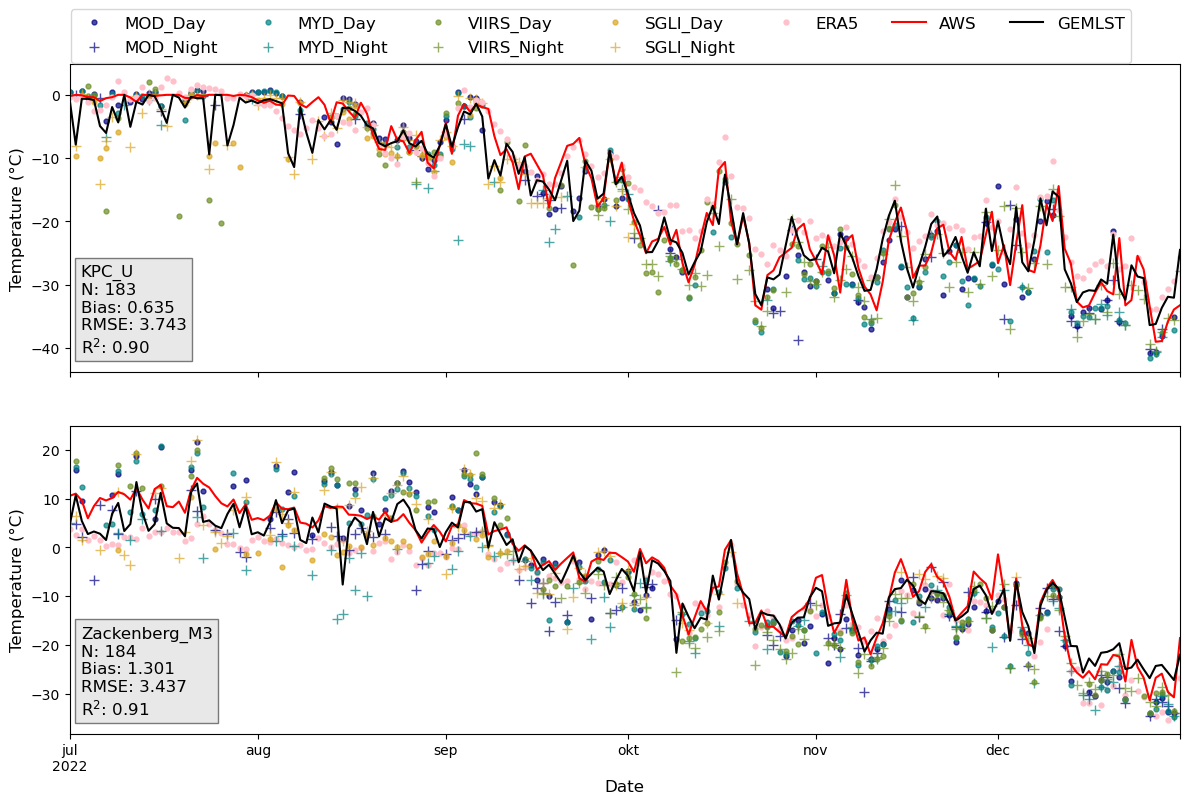

In [92]:
# Create a bbox with the stats for both datasets
stats_text_ice = (
    f"{station_ice}\n"
    f"N: {stats_ice['N']}\n"
    f"Bias: {stats_ice['bias']:.3f}\n"
    f"RMSE: {stats_ice['rmse']:.3f}\n"
    f"R$^2$: {stats_ice['$R^2$']:.2f}"
)

stats_text_land = (
    f"{station_land}\n"
    f"N: {stats_land['N']}\n"
    f"Bias: {stats_land['bias']:.3f}\n"
    f"RMSE: {stats_land['rmse']:.3f}\n"
    f"R$^2$: {stats_land['$R^2$']:.2f}"
)

bbox_props = dict(facecolor='lightgrey', alpha=0.5)

# Create time series plots for aws_land and ice 

fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)
fig.subplots_adjust(top=0.5)


ax1 = axes[0]
mod_day_ice.plot(x="date", y="MOD_LST_Day", ax=ax1, color='navy', linestyle='None', marker='.', markersize=7, alpha=0.7, label="MOD_Day", legend=False)
mod_night_ice.plot(x="date", y="MOD_LST_Night", ax=ax1, color='navy', linestyle='None', marker='+',  markersize=7, alpha=0.7, label="MOD_Night", legend=False)
myd_day_ice.plot(x="date", y="MYD_LST_Day", ax=ax1, color='teal', linestyle='None', marker='.', markersize=7, alpha=0.7, label="MYD_Day", legend=False)
myd_night_ice.plot(x="date", y="MYD_LST_Night", ax=ax1, color='teal', linestyle='None', marker='+',  markersize=7, alpha=0.7, label="MYD_Night", legend=False)
viirs_day_ice.plot(x="date", y="VIIRS_LST_1KM_C", ax=ax1, color='olivedrab', linestyle='None', marker='.', markersize=7, alpha=0.7, label="VIIRS_Day", legend=False)
viirs_night_ice.plot(x="date", y="VIIRS_LST_1KM_C", ax=ax1, color='olivedrab', linestyle='None', marker='+',  markersize=7, alpha=0.7, label="VIIRS_Night", legend=False)
sgli_ice_a.plot(x="date", y="JAXA_LST_AVE", ax=ax1, color='goldenrod', linestyle='None', marker='.', markersize=7, alpha=0.7, label="SGLI_Day", legend=False)
sgli_ice_d.plot(x="date", y="JAXA_LST_AVE", ax=ax1, color='goldenrod', linestyle='None', marker='+',  markersize=7, alpha=0.7, label="SGLI_Night", legend=False)
era5_ice.plot(x="date", y=station_ice, ax=ax1, color='pink', linestyle='None', marker='.', markersize=7, label="ERA5", legend=False)
aws_ice.plot(x="date", y="t_surf", ax=ax1, color='red', linestyle='-', label="AWS", linewidth=1.5, legend=False)
aws_ice.plot(x="date", y="RS_LST", ax=ax1, color='black', linestyle='-', label="GEMLST", linewidth=1.5, legend=False)
ax1.text(0.01, 0.35, stats_text_ice, transform=ax1.transAxes, fontsize=12, verticalalignment='top', bbox=bbox_props)
ax1.set_ylabel("Temperature (°C)", size=12)
ax1.tick_params(axis='x', which='minor', bottom=False, top=False, labelbottom=False)

ax2 = axes[1]
era5_land.plot(x="date", y=station_land, ax=ax2, color='pink', linestyle='None', marker='.', markersize=7, label="ERA5", legend=False)
mod_day_land.plot(x="date", y="MOD_LST_Day", ax=ax2, color='navy', linestyle='None', marker='.', markersize=7, alpha=0.7, label="MOD_Day", legend=False)
mod_night_land.plot(x="date", y="MOD_LST_Night", ax=ax2, color='navy', linestyle='None', marker='+',  markersize=7, alpha=0.7, label="MOD_Night", legend=False)
myd_day_land.plot(x="date", y="MYD_LST_Day", ax=ax2, color='teal', linestyle='None', marker='.', markersize=7, alpha=0.7, label="MYD_Day", legend=False)
myd_night_land.plot(x="date", y="MYD_LST_Night", ax=ax2, color='teal', linestyle='None', marker='+',  markersize=7, alpha=0.7, label="MYD_Night", legend=False)
viirs_day_land.plot(x="date", y="VIIRS_LST_1KM_C", ax=ax2, color='olivedrab', linestyle='None', marker='.', markersize=7, alpha=0.7, label="VIIRS_Day", legend=False)
viirs_night_land.plot(x="date", y="VIIRS_LST_1KM_C", ax=ax2, color='olivedrab', linestyle='None', marker='+',  markersize=7, alpha=0.7, label="VIIRS_Night", legend=False)
sgli_land_a.plot(x="date", y="JAXA_LST_AVE", ax=ax2, color='goldenrod', linestyle='None', marker='.', markersize=7,  alpha=0.7, label="SGLI_Day", legend=False)
sgli_land_d.plot(x="date", y="JAXA_LST_AVE", ax=ax2, color='goldenrod', linestyle='None', marker='+',  markersize=7, alpha=0.7, label="SGLI_Night", legend=False)
aws_land.plot(x="date", y="temperature", ax=ax2, color='red', linestyle='-', label="AWS", linewidth=1.5, legend=False)
aws_land.plot(x="date", y="RS_LST", ax=ax2, color='black', linestyle='-', label="GEMLST", linewidth=1.5, legend=False)
ax2.text(0.01, 0.35, stats_text_land, transform=ax2.transAxes, fontsize=12, verticalalignment='top', bbox=bbox_props)
ax2.set_ylabel("Temperature (°C)", size=12)
ax2.set_xlabel("Date", size=12)
ax2.tick_params(axis='x', which='minor', bottom=False, top=False, labelbottom=False)

# Create one legend for both subplots
handles1, labels1 = ax1.get_legend_handles_labels()
handles2, labels2 = ax2.get_legend_handles_labels()
# Combine handles and labels, ensuring no duplicates
handles = handles1 + handles2
labels = labels1 + labels2
# Create a dictionary to remove duplicates while preserving order
unique_labels = dict(zip(labels, handles))
# Create a single legend for both subplots
fig.legend(
    unique_labels.values(),
    unique_labels.keys(),
    loc="upper center",
    bbox_to_anchor=(0.505, 1.01),
    ncol=7,
    fontsize=12,
    # edgecolor='black', framealpha=0.5
)

plt.tight_layout(rect=[0, 0, 1, 0.95], h_pad=0.0)

# Export figure as PNG and PDF
fig.savefig(f"Time_series_{station_ice}_{station_land}.png", dpi=300)
fig.savefig(f"Time_series_{station_ice}_{station_land}.pdf", dpi=300)

plt.show()